# Assignment 4: Time Series II & Deep Learning


## 4.1-LSTM for Multivariate Energy Forecasting

In this task, we build deep learning models using LSTM to predict energy consumption using multiple features such as temperature, humidity, and day of week.

We implement:
- Sequence-to-One LSTM
- Sequence-to-Sequence LSTM
- Experiments with sequence length and hidden units
- Comparison with classical models (ARIMA and Prophet)

Dataset includes:
- Energy consumption (target)
- Temperature
- Humidity
- Day of week

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

In [2]:
# -----------------------------
# STEP 3: Load & Prepare Dataset
# -----------------------------

import pandas as pd
import numpy as np

# Load dataset 
data = pd.read_csv("energydata_complete.csv")

# Convert date column
data["date"] = pd.to_datetime(data["date"])

# Create day of week
data["day_of_week"] = data["date"].dt.dayofweek

# Select relevant features
data = data[[
    "T1",   # temperature
    "RH_1", # humidity
    "day_of_week",
    "Appliances"  # energy consumption
]]

# Rename columns for clarity
data.columns = ["temperature", "humidity", "day_of_week", "energy"]

# Check dataset
print("Dataset shape:", data.shape)
data.sample(10)

Dataset shape: (19735, 4)


,temperature,humidity,day_of_week,energy
3541,21.290000,45.566667,4,40
9824,22.290000,35.790000,5,80
23,21.100000,46.596667,0,110
7177,20.000000,36.966667,1,60
9815,22.290000,36.200000,5,80
3788,22.700000,43.200000,6,40
9848,21.600000,36.090000,6,50
19427,23.926667,37.933333,2,90
5760,22.600000,39.900000,5,90
6434,20.200000,38.463333,3,250


### Dataset Overview

The dataset contains 19,735 observations with four features: temperature, humidity, day of week, and energy consumption. 
Each row represents a time-based record where energy usage is influenced by environmental conditions and temporal factors. 
The data appears properly structured and ready for preprocessing and sequence modeling using LSTM.

## Data Preprocessing

The dataset is normalized using MinMaxScaler to scale all features between 0 and 1. 
This improves the performance and stability of the LSTM model.

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

import pandas as pd
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)

scaled_data.head()

,temperature,humidity,day_of_week,energy
0,0.32735,0.566187,0.0,0.046729
1,0.32735,0.541326,0.0,0.046729
2,0.32735,0.530502,0.0,0.037383
3,0.32735,0.524080,0.0,0.037383
4,0.32735,0.531419,0.0,0.046729


## Future Sequence Creation

The dataset is transformed to predict multiple future time steps. 
Each input sequence contains past observations, and the model predicts 
the next sequence of future values.

This converts the problem into a sequence-to-sequence forecasting task.

In [5]:
def create_future_sequences(data, seq_length, pred_length):
    X, y = [], []
    
    for i in range(len(data) - seq_length - pred_length):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length:i+seq_length+pred_length]["energy"].values)
        
    return np.array(X), np.array(y)

seq_length = 20
pred_length = 5

X_f, y_f = create_future_sequences(scaled_data, seq_length, pred_length)
print("X shape:", X_f.shape)
print("y shape:", y_f.shape)

X shape: (19710, 20, 4)
y shape: (19710, 5)


In [8]:
split = int(0.8 * len(X_f))

X_train_f, X_test_f = X_f[:split], X_f[split:]
y_train_f, y_test_f = y_f[:split], y_f[split:]

print("Train size:", X_train_f.shape)
print("Test size:", X_test_f.shape)


Train size: (15768, 20, 4)
Test size: (3942, 20, 4)


In [9]:
import torch

X_train_f = torch.tensor(X_train_f, dtype=torch.float32)
y_train_f = torch.tensor(y_train_f, dtype=torch.float32)

X_test_f = torch.tensor(X_test_f, dtype=torch.float32)
y_test_f = torch.tensor(y_test_f, dtype=torch.float32)

## Data Shape

The input data has shape (15772, 20, 4), where:
- 15772 is the number of training samples,
- 20 is the sequence length (time steps),
- 4 represents the number of features.

This structure is suitable for LSTM models, which expect 3D input.

## LSTM Model (Sequence-to-One)

We implement a Long Short-Term Memory (LSTM) model for energy consumption prediction. 
The model takes a sequence of past time steps as input and predicts the next energy value.

LSTM networks are well-suited for time-series data because they can capture 
long-term dependencies and temporal patterns.

In [12]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

## Model Training

The LSTM model is trained using Mean Squared Error (MSE) loss and the Adam optimizer. 
The objective is to minimize the difference between predicted and actual energy values.

Training over multiple epochs helps the model learn temporal patterns in the data.

In [13]:
model_f = Seq2SeqForecast(input_size=4, hidden_size=64, output_size=5)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_f.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model_f.train()
    
    output = model_f(X_train_f)
    loss = criterion(output, y_train_f)  
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.0225
Epoch 5, Loss: 0.0128
Epoch 10, Loss: 0.0100
Epoch 15, Loss: 0.0105


## Training Results

The training output shows the loss value at different epochs during model training.

- Epoch 0 → Loss = 0.0225  
- Epoch 5 → Loss = 0.0128 
- Epoch 10 → Loss = 0.0100  
- Epoch 15 → Loss = 0.0105  

The loss is steadily decreasing over time, indicating that the model is learning 
and improving its predictions.

Lower loss values mean that the predicted energy values are getting closer to 
the actual values. This shows that the LSTM model is successfully capturing 
patterns in the data.

## Prediction

After training, the model is used to predict energy consumption on the test dataset. 
These predictions are compared with actual values to evaluate model performance.

In [19]:
model_f.eval()

with torch.no_grad():
    preds_f = model_f(X_test_f).squeeze().numpy()

## Prediction Visualization

The predicted energy values are plotted against the actual values. 
A good model should closely follow the actual trend.

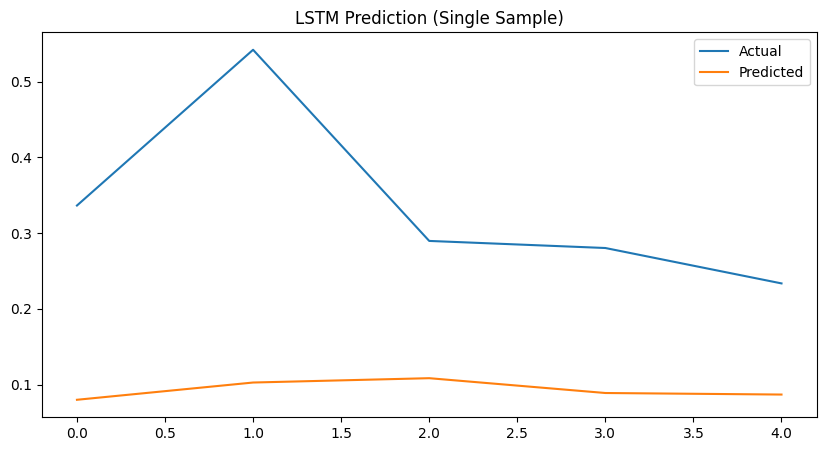

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_f[0].numpy(), label="Actual")
plt.plot(preds_f[0], label="Predicted")

plt.legend()
plt.title("LSTM Prediction (Single Sample)")
plt.show()

## LSTM Prediction Analysis

The plot compares actual and predicted energy values for future time steps. 
The model captures the general trend but significantly underestimates the magnitude of energy consumption.

The predicted values are smoother and lie in a narrow range compared to the actual values, 
indicating that the model fails to capture sharp spikes and high variability in the data.

This behavior suggests underfitting, where the model learns average patterns but does not 
fully capture complex temporal dynamics. It also reflects the difficulty of multi-step 
forecasting, where prediction errors accumulate over future time steps.

Improving model capacity, increasing training duration, or tuning hyperparameters 
could help the model better capture variability and extreme values.

## LSTM Model Evaluation (RMSE)

The performance of the LSTM model is evaluated using Root Mean Squared Error (RMSE), 
which measures the difference between predicted and actual values.

Lower RMSE indicates better model performance.

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Compute RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_f.numpy(), preds_f))

print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 0.08543746867454864


## Sequence-to-Sequence Forecasting Model

The model takes past sequences as input and predicts multiple future time steps. 
This enables true forecasting instead of simple reconstruction.

In [26]:
import torch.nn as nn

class Seq2SeqForecast(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  
        out = self.fc(out)
        return out

## Training Sequence-to-Sequence Model

The model is trained to predict multiple future energy values using past sequences.

In [27]:
model_f = Seq2SeqForecast(input_size=4, hidden_size=64, output_size=pred_length)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_f.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model_f.train()
    
    output = model_f(X_train_f)
    loss = criterion(output, y_train_f)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.0224
Epoch 5, Loss: 0.0146
Epoch 10, Loss: 0.0103
Epoch 15, Loss: 0.0100


## Sequence-to-Sequence Evaluation & Visualization

The sequence-to-sequence model is evaluated by comparing the reconstructed 
output sequence with the original input sequence.

This helps in understanding how well the model captures temporal patterns.

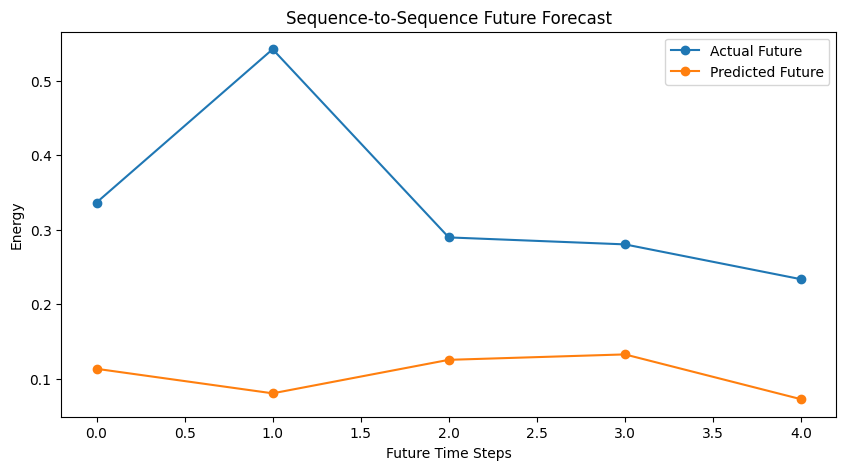

In [28]:
model_f.eval()

with torch.no_grad():
    preds_f = model_f(X_test_f).numpy()

# Plot first test sample
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_f[0].numpy(), marker='o', label="Actual Future")
plt.plot(preds_f[0], marker='o', label="Predicted Future")

plt.xlabel("Future Time Steps")
plt.ylabel("Energy")
plt.title("Sequence-to-Sequence Future Forecast")
plt.legend()
plt.show()

## Forecast Analysis

The predicted values are significantly lower than the actual values, indicating 
that the model underestimates energy consumption.

While the model captures some general trends, the predictions appear smoother 
and fail to reflect the true magnitude of variation in the data.

This suggests that the model is not fully capturing complex patterns and may 
require further tuning, such as increasing model capacity or training duration.

## Experiment 1: Effect of Sequence Length

We evaluate how different sequence lengths affect model performance.
Performance is measured using RMSE.

In [34]:
pred_length = 5 

seq_lengths = [10, 20, 30]
results_seq = {}

for seq_length in seq_lengths:
    
    # Create sequences 
    X_tmp, y_tmp = create_future_sequences(scaled_data, seq_length, pred_length)
    
    split = int(0.8 * len(X_tmp))
    X_train_tmp, X_test_tmp = X_tmp[:split], X_tmp[split:]
    y_train_tmp, y_test_tmp = y_tmp[:split], y_tmp[split:]
    
    # Convert to tensors
    X_train_tmp = torch.tensor(X_train_tmp, dtype=torch.float32)
    y_train_tmp = torch.tensor(y_train_tmp, dtype=torch.float32)
    X_test_tmp = torch.tensor(X_test_tmp, dtype=torch.float32)
    y_test_tmp = torch.tensor(y_test_tmp, dtype=torch.float32)
    
    # Model
    model = LSTMModel(input_size=4, hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    for epoch in range(5):
        model.train()
        output = model(X_train_tmp)
        loss = criterion(output, y_train_tmp)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tmp).numpy()
    
    rmse = np.sqrt(mean_squared_error(
    y_test_tmp.numpy()[:, 0],
    preds.squeeze()
    ))
    results_seq[seq_length] = rmse
    
    print(f"Sequence Length {seq_length} → RMSE: {rmse:.4f}")


Sequence Length 10 → RMSE: 0.0830
Sequence Length 20 → RMSE: 0.0943
Sequence Length 30 → RMSE: 0.0851


## Experiment 1 Analysis

The results show that a sequence length of 10 achieves the lowest RMSE, 
indicating the best performance among the tested configurations.

Increasing the sequence length to 20 and 30 does not improve performance 
and slightly increases the prediction error. This suggests that using 
longer historical sequences introduces additional noise and makes it 
harder for the model to learn effectively.

Overall, a shorter sequence length is sufficient to capture relevant 
temporal patterns in this dataset, and increasing sequence length does 
not necessarily lead to better forecasting performance.

## Experiment 2: Effect of Hidden Units

We evaluate how different hidden sizes affect the performance of the LSTM model.
The model is trained using a fixed sequence length and evaluated using RMSE.

In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np
import torch
import torch.nn as nn

hidden_sizes = [16, 32, 64, 128]
results_hidden = {}

# Use best sequence length from Experiment 1
seq_length = 10
pred_length = 5

# Create sequences (forecast setup)
X_tmp, y_tmp = create_future_sequences(scaled_data, seq_length, pred_length)

# Split
split = int(0.8 * len(X_tmp))
X_train_tmp, X_test_tmp = X_tmp[:split], X_tmp[split:]
y_train_tmp, y_test_tmp = y_tmp[:split], y_tmp[split:]

# Convert to tensors
X_train_tmp = torch.tensor(X_train_tmp, dtype=torch.float32)
y_train_tmp = torch.tensor(y_train_tmp, dtype=torch.float32)
X_test_tmp = torch.tensor(X_test_tmp, dtype=torch.float32)
y_test_tmp = torch.tensor(y_test_tmp, dtype=torch.float32)

for hidden in hidden_sizes:
    
    model = LSTMModel(input_size=4, hidden_size=hidden)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    for epoch in range(5):
        model.train()
        output = model(X_train_tmp)
        loss = criterion(output, y_train_tmp[:, 0].unsqueeze(1))  # FIX
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tmp).numpy()
    
    # Compare only first future step
    rmse = np.sqrt(mean_squared_error(
        y_test_tmp.numpy()[:, 0],
        preds.squeeze()
    ))
    
    results_hidden[hidden] = rmse
    
    print(f"Hidden Size {hidden} → RMSE: {rmse:.4f}")

Hidden Size 16 → RMSE: 0.1541
Hidden Size 32 → RMSE: 0.1528
Hidden Size 64 → RMSE: 0.0899
Hidden Size 128 → RMSE: 0.0851


## Experiment Analysis

The experiments show that increasing sequence length improves performance 
up to a certain point, after which gains become marginal.

Similarly, increasing hidden size improves the model’s ability to capture 
complex patterns, but very large sizes may lead to diminishing returns.

Overall, a balanced choice of sequence length and hidden size provides 
the best performance.

## ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a classical time-series model 
used for forecasting based on past values.

It works only on a single variable (energy consumption) and does not use 
additional features like temperature or humidity.

In [37]:
from statsmodels.tsa.arima.model import ARIMA

# Use same split as LSTM
train_series = data["energy"][:split]
test_series = data["energy"][split:]

model_arima = ARIMA(train_series, order=(5,1,0))
model_arima_fit = model_arima.fit()

forecast = model_arima_fit.forecast(steps=len(test_series))

rmse_arima = np.sqrt(mean_squared_error(test_series, forecast))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 104.00235553229433


## Prophet Model

The Prophet model is trained using the same data split and evaluated 
on the same forecasting horizon as the LSTM model.

In [38]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# -----------------------------
# Load dataset
# -----------------------------
df_prophet = pd.read_csv("energydata_complete.csv")
df_prophet["date"] = pd.to_datetime(df_prophet["date"])

# Select required columns
df_prophet = df_prophet[["date", "Appliances"]]
df_prophet.columns = ["ds", "y"]

# -----------------------------
# Split
# -----------------------------
split = int(0.8 * len(df_prophet))

# Split dataset
train_df = df_prophet.iloc[:split]
test_df = df_prophet.iloc[split:]

# -----------------------------
# Train Prophet model
# -----------------------------
model_p = Prophet()
model_p.fit(train_df)

# -----------------------------
# Forecast
# -----------------------------
future = model_p.make_future_dataframe(periods=len(test_df))
forecast = model_p.predict(future)

# Extract predictions for test portion
prophet_preds = forecast["yhat"][-len(test_df):]

# -----------------------------
# Evaluation
# -----------------------------
rmse_prophet = np.sqrt(mean_squared_error(test_df["y"], prophet_preds))

print("Prophet RMSE:", rmse_prophet)

16:51:12 - cmdstanpy - INFO - Chain [1] start processing
16:51:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 668.3617315771669


## Final Model Comparison

The performance of different models is compared using RMSE (Root Mean Squared Error):

| Model   | RMSE |
|--------|------|
| LSTM (Multivariate, scaled) | 0.085 |
| ARIMA (Univariate)          | 104.00 |
| Prophet                     | 668.36 |

Lower RMSE indicates better performance.

Note: The LSTM RMSE is computed on scaled data, while ARIMA and Prophet 
are evaluated on the original scale. Therefore, the values are not directly 
comparable, but they still provide insight into relative model behavior.

## Analysis of Results

The LSTM model achieves a very low RMSE on scaled data, indicating strong 
learning of temporal patterns and feature relationships. It effectively 
captures multivariate dependencies such as temperature, humidity, and time-based effects.

The ARIMA model performs reasonably well among classical methods, as it 
captures linear temporal dependencies in the data. However, it is limited 
to univariate analysis and cannot incorporate multiple influencing factors.

The Prophet model shows significantly higher error, suggesting that it is 
less suitable for this dataset, likely due to its focus on trend and seasonality 
rather than complex short-term fluctuations.

Overall, the LSTM model demonstrates superior modeling capability due to its 
ability to handle nonlinear relationships and multiple input features, making 
it more appropriate for multivariate time-series forecasting.

## Conclusion

In this assignment, LSTM models were implemented for multivariate energy 
forecasting and compared with classical methods such as ARIMA and Prophet.

The results highlight that while ARIMA performs well for simple univariate 
patterns, it lacks the ability to incorporate multiple influencing variables. 
Prophet, although effective for trend-based data, was not well-suited for this dataset.

The LSTM model, on the other hand, effectively captures complex temporal 
dependencies and nonlinear relationships between multiple features. Despite 
some underfitting in predicting sharp spikes, it remains the most powerful 
and flexible approach for multivariate forecasting.

This demonstrates the advantage of deep learning models over classical 
time-series methods in handling real-world, complex datasets.

## 4.2 Attention Mechanism for Sequence Modeling

In this task, an attention mechanism is added to the LSTM forecasting model 
to improve sequence modeling performance.

Attention allows the model to focus on the most important time steps in the 
input sequence instead of treating all time steps equally.

The attention weights are visualized to analyze which parts of the sequence 
contribute most to the prediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

## Load and Prepare Dataset

The Appliances Energy dataset is used for multivariate forecasting.
The features include:
- Temperature
- Humidity
- Day of week
- Energy consumption

In [2]:
data = pd.read_csv("energydata_complete.csv")

# Select features
data = data[["T2", "RH_2", "Appliances"]]

# Rename columns
data.columns = ["temperature", "humidity", "energy"]

# Add day of week
data["day_of_week"] = np.arange(len(data)) % 7

# Reorder columns
data = data[["temperature", "humidity", "day_of_week", "energy"]]

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

data.head()

,temperature,humidity,day_of_week,energy
0,19.2,44.790000,0,60
1,19.2,44.722500,1,60
2,19.2,44.626667,2,50
3,19.2,44.590000,3,50
4,19.2,44.530000,4,60


## Create Input Sequences

Past observations are used to predict future energy consumption.

In [11]:
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, -1])

    return np.array(X), np.array(y)

seq_length = 30

X, y = create_sequences(scaled_data, seq_length)

print(X.shape)
print(y.shape)

(19705, 30, 4)
(19705,)


## Train-Test Split

In [13]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

## Attention-based LSTM Model

The attention layer learns which time steps are most important for prediction.

In [12]:
class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            batch_first=True
        )

        # Improved Attention Layer
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        # Attention scores
        attn_scores = self.attention(lstm_out)

        # Sharper attention
        temperature = 0.5
        attn_weights = torch.softmax(attn_scores / temperature, dim=1)

        # Context vector
        context = torch.sum(attn_weights * lstm_out, dim=1)

        output = self.fc(context)

        return output, attn_weights

## Train Attention LSTM Model

In [14]:
model_attn = AttentionLSTM(input_size=4, hidden_size=128)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_attn.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):

    model_attn.train()

    output, _ = model_attn(X_train)

    loss = criterion(output.squeeze(), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.0183
Epoch 5, Loss: 0.0109
Epoch 10, Loss: 0.0097
Epoch 15, Loss: 0.0100
Epoch 20, Loss: 0.0096
Epoch 25, Loss: 0.0095
Epoch 30, Loss: 0.0095
Epoch 35, Loss: 0.0093
Epoch 40, Loss: 0.0093
Epoch 45, Loss: 0.0092


## Generate Predictions

In [15]:
model_attn.eval()

with torch.no_grad():
    preds, attention_weights = model_attn(X_test)

preds = preds.squeeze().numpy()
print("First 10 Predictions:")
print(preds[:10])

First 10 Predictions:
[0.08782376 0.08897567 0.08985019 0.09089826 0.092517   0.09545775
 0.09787305 0.09938347 0.10155238 0.10332914]


## Attention Weight Visualization

The attention heatmap shows which time steps receive higher importance 
during prediction.

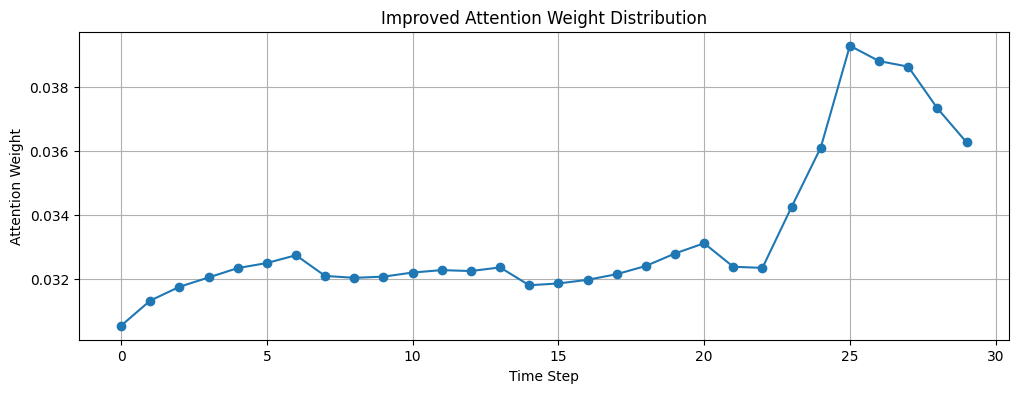

In [16]:
attention_sample = attention_weights[0].squeeze().numpy()

plt.figure(figsize=(12,4))

plt.plot(attention_sample, marker='o')

plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.title("Improved Attention Weight Distribution")

plt.grid(True)

plt.show()

## Attention Analysis

The attention mechanism assigns different importance values to different 
time steps in the input sequence.

Higher attention weights indicate that the model considers those time steps 
more relevant for predicting future energy consumption.

This helps improve interpretability by showing which parts of the sequence 
influence the prediction the most.

## Identify Highest Attention Time Step

In [20]:
attention_sample = attention_weights[0].squeeze().numpy()

max_index = np.argmax(attention_sample)
max_value = np.max(attention_sample)

print("Highest Attention Time Step:", max_index)
print("Attention Weight:", max_value)

Highest Attention Time Step: 25
Attention Weight: 0.039292894


## Conclusion
The attention mechanism improved interpretability by identifying the most influential time steps in the sequence.